In [197]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    silhouette_score,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [198]:
path = "/content/online_retail_II.csv"

df = pd.read_csv(path, encoding="latin1")

In [199]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [201]:
print(df.shape)

(541910, 8)


In [202]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [203]:
df = df.dropna()

In [204]:
print(df.shape)

(406830, 8)


In [205]:
# Total amount spending on each purchase

df["Total_Amount"] = df["Quantity"] * df["Price"]

In [206]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34


In [207]:
# Converting invoice date into datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],
    dayfirst=True
)

In [208]:
snapshot_date = df["InvoiceDate"].max()

print(snapshot_date)

2011-12-09 12:50:00


In [209]:
customer_data = df.groupby("Customer ID").agg({

    "Invoice": "nunique",
    "Total_Amount": "sum",
    "Quantity": "sum",
    "InvoiceDate": "max"

})

In [210]:
customer_data.head()

,Invoice,Total_Amount,Quantity,InvoiceDate
Customer ID,,,,
12346.0,2,0.00,0,2011-01-18 10:17:00
12347.0,7,4310.00,2458,2011-12-07 15:52:00
12348.0,4,1797.24,2341,2011-09-25 13:13:00
12349.0,1,1757.55,631,2011-11-21 09:51:00
12350.0,1,334.40,197,2011-02-02 16:01:00


In [211]:
customer_data.columns = [
    "Total_Orders",
    "Total_Spend",
    "Total_Items",
    "Last_Purchase"
]

In [212]:
customer_data.head()

,Total_Orders,Total_Spend,Total_Items,Last_Purchase
Customer ID,,,,
12346.0,2,0.00,0,2011-01-18 10:17:00
12347.0,7,4310.00,2458,2011-12-07 15:52:00
12348.0,4,1797.24,2341,2011-09-25 13:13:00
12349.0,1,1757.55,631,2011-11-21 09:51:00
12350.0,1,334.40,197,2011-02-02 16:01:00


In [213]:
customer_data["Recency"] = (snapshot_date - customer_data["Last_Purchase"]).dt.days

customer_data.head()

,Total_Orders,Total_Spend,Total_Items,Last_Purchase,Recency
Customer ID,,,,,
12346.0,2,0.00,0,2011-01-18 10:17:00,325
12347.0,7,4310.00,2458,2011-12-07 15:52:00,1
12348.0,4,1797.24,2341,2011-09-25 13:13:00,74
12349.0,1,1757.55,631,2011-11-21 09:51:00,18
12350.0,1,334.40,197,2011-02-02 16:01:00,309


In [214]:
customer_data.drop("Last_Purchase", axis=1, inplace=True)

customer_data.head()

,Total_Orders,Total_Spend,Total_Items,Recency
Customer ID,,,,
12346.0,2,0.00,0,325
12347.0,7,4310.00,2458,1
12348.0,4,1797.24,2341,74
12349.0,1,1757.55,631,18
12350.0,1,334.40,197,309


In [215]:
scaler = StandardScaler()

features = customer_data[[
    "Total_Orders",
    "Total_Items",
    "Recency"
]]
scaled_features = scaler.fit_transform(features)

In [216]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

customer_data["Cluster"] = kmeans.fit_predict(scaled_features)

In [217]:
score = silhouette_score(
    scaled_features,
    customer_data["Cluster"]
)

print("Silhouette Score :", score)

Silhouette Score : 0.5846422049211655


In [218]:
customer_data["Cluster"].value_counts()

,count
Cluster,
0,3243
1,1107
2,22


In [219]:
customer_data.groupby("Cluster").mean()

,Total_Orders,Total_Spend,Total_Items,Recency
Cluster,,,,
0,5.606229,1839.783054,1096.114709,39.018501
1,1.847335,459.407011,259.574526,245.173442
2,89.272727,82959.264091,48401.818182,5.181818


In [220]:
# Cluster naming

cluster_names = {
    0: "Low Value",
    1: "Premium",
    2: "Regular"
}

customer_data["Customer_Segment"] = customer_data["Cluster"].map(cluster_names)

In [221]:
customer_data.head()

,Total_Orders,Total_Spend,Total_Items,Recency,Cluster,Customer_Segment
Customer ID,,,,,,
12346.0,2,0.00,0,325,1,Premium
12347.0,7,4310.00,2458,1,0,Low Value
12348.0,4,1797.24,2341,74,0,Low Value
12349.0,1,1757.55,631,18,0,Low Value
12350.0,1,334.40,197,309,1,Premium


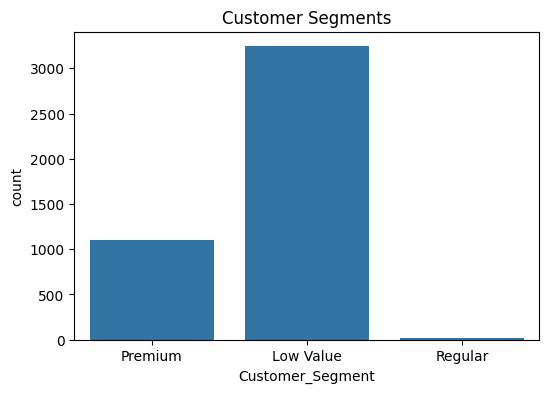

In [222]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=customer_data,
    x="Customer_Segment"
)

plt.title("Customer Segments")

plt.show()

In [223]:
# regression modeling
# consider how often a customer buys

customer_data["CLV"] = (
    customer_data["Total_Spend"] *
    customer_data["Total_Orders"]
)

In [224]:
X = customer_data[
    [
        "Total_Orders",
        "Total_Items",
        "Recency"
    ]
]

y = customer_data["CLV"]

Feature as Total_Spend

Target as CLV (= Total_Spend)


In [225]:
# Spliting the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [226]:
# Training of Regression Model

model = RandomForestRegressor(
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [227]:
# Predicting CLV

y_pred = model.predict(X_test)

In [228]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("RMSE :", rmse)
print("R² Score :", r2)
print("MAPE :", mape)

RMSE : 194621.21901458444
R² Score : 0.8912059004875594
MAPE : 15144211575534.576


In [229]:
joblib.dump(scaler,"scaler.pkl")
joblib.dump(kmeans,"customer_segmentation_model.pkl")

print("Models Saved Successfully!")

Models Saved Successfully!


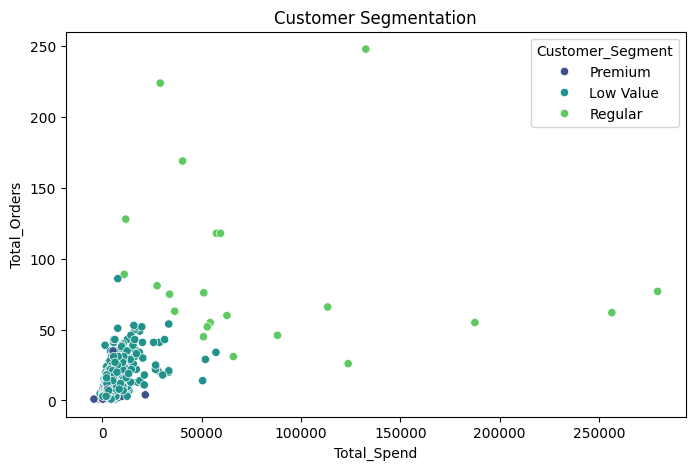

In [230]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=customer_data,
    x="Total_Spend",
    y="Total_Orders",
    hue="Customer_Segment",
    palette="viridis"
)

plt.title("Customer Segmentation")
plt.show()